##### feature
- age: 나이
- sex: 성별
- cp: chest pain type (4 values) 흉통 유형
- trestbps: resting blood pressure 안정시 혈압
- chol: serum cholesterol in mg/dl 혈청 콜레스테롤
- fbs: fasting blood sugar > 120 mg/dl 공복혈당이 120 넘는지 여부
- restecg: resting electrocardiographic results (values 0,1,2) 안정시 심전도 결과
- thalach: maximum heart rate achieved 최대 심박수
- exang: exercise induced angina 협심증 여부
- oldpeak: ST depression induced by exercise relative to rest 운동 중에 심전도의 ST 분절이 하강하는 현상
- slope: the slope of the peak exercise ST segment 운동(Peak)을 했을 때 ST 분절의 기울기
- ca: number of major vessels (0-3) colored by flourosopy 심장 관련 검사(CT, 조영술 등)에서 협착이나 폐색이 발생한 주요 관상동맥의 개수
- thal: 지중해빈혈 0 = normal 정상 ; 1 = fixed defect 고정 결함 ; 2 = reversable defect 가역적 결함 
##### target
- target: 심장병

### 오차 행렬, 정밀도, 재현율

In [1]:
import pandas as pd
import numpy as np

heart_df = pd.read_csv('../b_classifier/datasets/heart.csv')
heart_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [7]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
heart_df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
heart_df.duplicated().sum()

np.int64(723)

In [10]:
heart_df.drop_duplicates(ignore_index=True, inplace=True)
heart_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
298,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
299,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
300,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [11]:
heart_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [12]:
heart_df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [13]:
heart_df.columns = ['나이', '성별', '흉통유형', '혈압', '콜레스테롤', '공복혈당120이상', '심전도', '최대심박수', 
       '협심증', 'ST저하', 'ST기울기', '협착된동맥수', '지중해빈혈', '심장병']

In [14]:
heart_df.describe().T


,count,mean,std,min,25%,50%,75%,max
나이,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
성별,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
흉통유형,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
혈압,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
콜레스테롤,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
공복혈당120이상,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
심전도,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
최대심박수,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
협심증,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
ST저하,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [15]:
# 해당 feature들이 범주형인걸 확인할수 있었습니다.

heart_df['흉통유형'].value_counts()
# heart_df['심전도'].value_counts()
# heart_df['ST기울기'].value_counts()
# heart_df['협착된동맥수'].value_counts()
# heart_df['지중해빈혈'].value_counts()
# heart_df['심장병여부'].value_counts()

흉통유형
0    143
2     86
1     50
3     23
Name: count, dtype: int64

In [16]:
heart_df.sort_values(by='혈압', ascending=False).head(20)
heart_df.sort_values(by='콜레스테롤', ascending=False).head(20)

,나이,성별,흉통유형,혈압,콜레스테롤,공복혈당120이상,심전도,최대심박수,협심증,ST저하,ST기울기,협착된동맥수,지중해빈혈,심장병
128,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
104,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
144,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
260,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0
183,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
38,65,0,2,160,360,0,0,151,0,0.8,2,0,2,1
134,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
181,55,1,0,132,353,0,1,132,1,1.2,1,1,3,0
41,55,0,1,132,342,0,1,166,0,1.2,2,0,2,1
11,43,0,0,132,341,1,0,136,1,3.0,1,0,3,0


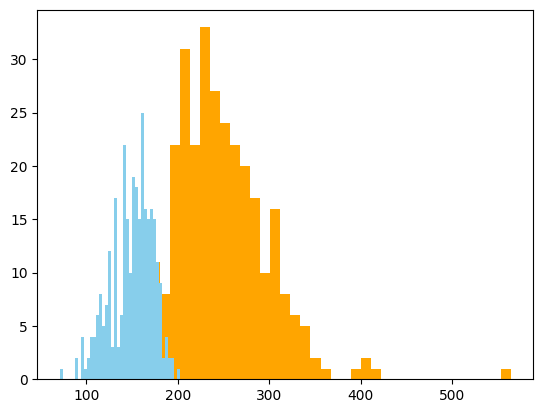

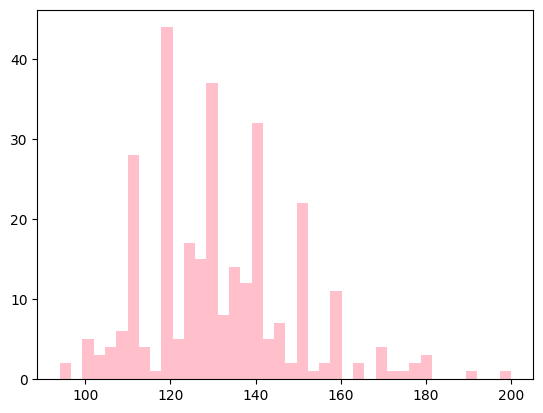

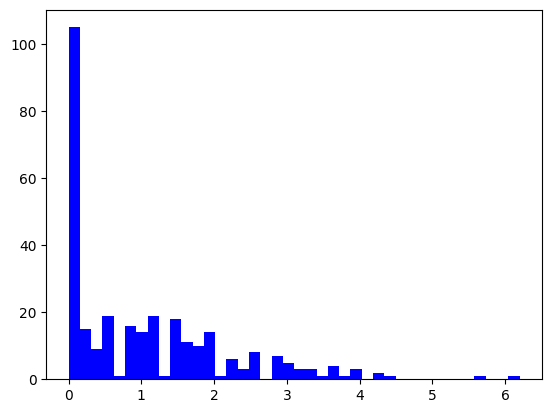

In [17]:
import matplotlib.pyplot as plt

plt.hist(heart_df['콜레스테롤'], bins=40, color='orange')
plt.hist(heart_df['최대심박수'], bins=40, color='skyblue')
plt.show()

plt.hist(heart_df['혈압'], bins=40, color='pink')
plt.show()

plt.hist(heart_df['ST저하'], bins=40, color='blue')
plt.show()

#### ST저하는 iqr로 작업, 나머지는 표준화작업을 진행하겠습니다

In [18]:
heart_df.describe().T

,count,mean,std,min,25%,50%,75%,max
나이,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
성별,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
흉통유형,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
혈압,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
콜레스테롤,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
공복혈당120이상,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
심전도,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
최대심박수,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
협심증,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
ST저하,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [19]:
# continuous_features = ['콜레스테롤', '최대심박수', '혈압', 'ST저하']
continuous_features = ['콜레스테롤', '최대심박수', '혈압']

total_count = heart_df.shape[0]

for feature in continuous_features:
    zero_count = heart_df[heart_df[feature] == 0][feature].count()
    print(f'{feature}: {zero_count}건, {np.round(zero_count / total_count * 100, 4)}%')



콜레스테롤: 0건, 0.0%
최대심박수: 0건, 0.0%
혈압: 0건, 0.0%


#### ST저하 칼럼의 원래 이름과 설명인 oldpeak ST depression induced by exercise relative to rest 운동 중에 심전도의 ST 분절이 하강하는 현상
##### 을 찾아보니 0의 경우는 정상인의 범주에 들어가는 특징이므로 0인 데이터들은 의미가 있는 데이터였습니다.

In [20]:
# 0을 가지는 개수확인

# zero_features = ['ST저하']

In [21]:
# heart_df[continuous_features] = heart_df[continuous_features].replace(0, heart_df[continuous_features].mean())

# continuous_features = ['콜레스테롤', '최대심박수', '혈압', 'ST저하']

# total_count = heart_df.shape[0]

# for feature in continuous_features:
#     zero_count = heart_df[heart_df[feature] == 0][feature].count()
#     print(f'{feature}: {zero_count}건, {np.round(zero_count / total_count * 100, 4)}%')

In [22]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()
std_zero = std.fit_transform(heart_df[continuous_features])
std_zero

array([[-0.66772815,  0.80603539, -0.37655636],
       [-0.84191811,  0.23749516,  0.47891019],
       [-1.40319685, -1.07452077,  0.76406571],
       [-0.84191811,  0.49989834,  0.93515902],
       [ 0.91933586, -1.90546419,  0.36484799],
       [ 0.02903166, -1.20572236, -1.80233394],
       [ 1.38384241, -0.41851281, -1.0038985 ],
       [ 0.82256367, -0.19984349,  1.61953226],
       [ 0.0483861 , -0.24357735, -0.66171188],
       [ 0.76450035, -1.46812555, -0.54764967],
       [-1.88705783, -1.07452077, -1.1179607 ],
       [ 1.82899451, -0.59344826,  0.02266137],
       [-0.70643703,  1.85564814, -0.77577408],
       [ 0.99675362, -1.20572236,  0.47891019],
       [-0.82256367,  0.28122902, -0.20546305],
       [ 1.19029801, -0.33104508,  0.47891019],
       [ 0.37741157, -1.7742626 , -0.43358746],
       [-0.0483861 ,  0.54363221, -0.66171188],
       [-0.68708259,  0.6748338 ,  0.47891019],
       [-1.19029801,  0.23749516,  0.47891019],
       [-0.45482932, -0.33104508, -1.460

In [23]:
pre_heart_df = heart_df.copy()
pre_heart_df[continuous_features] = std_zero
pre_heart_df

,나이,성별,흉통유형,혈압,콜레스테롤,공복혈당120이상,심전도,최대심박수,협심증,ST저하,ST기울기,협착된동맥수,지중해빈혈,심장병
0,52,1,0,-0.376556,-0.667728,0,1,0.806035,0,1.0,2,2,3,0
1,53,1,0,0.478910,-0.841918,1,0,0.237495,1,3.1,0,0,3,0
2,70,1,0,0.764066,-1.403197,0,1,-1.074521,1,2.6,0,0,3,0
3,61,1,0,0.935159,-0.841918,0,1,0.499898,0,0.0,2,1,3,0
4,62,0,0,0.364848,0.919336,1,1,-1.905464,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,68,0,2,-0.661712,-0.687083,0,0,-1.511859,0,1.5,1,0,2,1
298,44,0,2,-1.346085,-2.041893,0,1,1.112172,0,0.6,1,0,2,1
299,52,1,0,-0.205463,0.164513,0,1,0.499898,1,0.0,2,1,3,0
300,59,1,3,1.619532,0.512893,0,0,-1.074521,0,0.0,2,0,2,0


In [24]:
# 그냥 조건식을 쓰면 안됨!!
# condition1 = pre_d_df[continuous_features] >= -1.96
# condition2 = pre_d_df[continuous_features] <= 1.96

# 하나의 조건이라도 만족하는 행
# condition1 = (pre_d_df[continuous_features] >= -3).any(axis=1)
# condition2 = (pre_d_df[continuous_features] <= 3).any(axis=1)

# 모든 조건이 만족하는 행
condition1 = (pre_heart_df[continuous_features] >= -3).all(axis=1)
condition2 = (pre_heart_df[continuous_features] <= 3).all(axis=1)
condition = condition1 & condition2

pre_heart_df = pre_heart_df[condition]
pre_heart_df

,나이,성별,흉통유형,혈압,콜레스테롤,공복혈당120이상,심전도,최대심박수,협심증,ST저하,ST기울기,협착된동맥수,지중해빈혈,심장병
0,52,1,0,-0.376556,-0.667728,0,1,0.806035,0,1.0,2,2,3,0
1,53,1,0,0.478910,-0.841918,1,0,0.237495,1,3.1,0,0,3,0
2,70,1,0,0.764066,-1.403197,0,1,-1.074521,1,2.6,0,0,3,0
3,61,1,0,0.935159,-0.841918,0,1,0.499898,0,0.0,2,1,3,0
4,62,0,0,0.364848,0.919336,1,1,-1.905464,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,68,0,2,-0.661712,-0.687083,0,0,-1.511859,0,1.5,1,0,2,1
298,44,0,2,-1.346085,-2.041893,0,1,1.112172,0,0.6,1,0,2,1
299,52,1,0,-0.205463,0.164513,0,1,0.499898,1,0.0,2,1,3,0
300,59,1,3,1.619532,0.512893,0,0,-1.074521,0,0.0,2,0,2,0


In [25]:
heart_df = heart_df.iloc[pre_heart_df.index.values, :].reset_index(drop=True)
heart_df

,나이,성별,흉통유형,혈압,콜레스테롤,공복혈당120이상,심전도,최대심박수,협심증,ST저하,ST기울기,협착된동맥수,지중해빈혈,심장병
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
291,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
292,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
293,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [26]:
Q1 = heart_df['ST저하'].describe().T['25%']
Q3 = heart_df['ST저하'].describe().T['75%']

iqr = Q3 - Q1

lower_bound = Q1 - 1.5 * iqr
upper_bound = Q3 + 1.5 * iqr
if lower_bound < 0:
    lower_bound = 0
print(f'{lower_bound}~{upper_bound}')

0~4.0


In [27]:
heart_df = heart_df[heart_df['ST저하'] < upper_bound].reset_index(drop=True)
heart_df

,나이,성별,흉통유형,혈압,콜레스테롤,공복혈당120이상,심전도,최대심박수,협심증,ST저하,ST기울기,협착된동맥수,지중해빈혈,심장병
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
285,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
286,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
287,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [28]:
# 이미 파일에서 범주형들 대부분이 되어있음. 
# 인코딩 이진도 아니고 target도 아닌것 => 흉통유형, 심전도, ST기울기, 협착된동맥수 4개.

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

chest_encoder = OneHotEncoder(sparse_output=False)
chest_onehot = chest_encoder.fit_transform(heart_df[['흉통유형']])
chest_cols = chest_encoder.get_feature_names_out(['흉통유형'])
chest_onehot_df = pd.DataFrame(data=chest_onehot, columns=chest_cols)
heart_enc_df = pd.concat([heart_df.iloc[:, :-1], chest_onehot_df], axis=1)
heart_enc_df['흉통유형'] = heart_df['흉통유형']
heart_enc_df

sim_encoder = OneHotEncoder(sparse_output=False)
sim_onehot = sim_encoder.fit_transform(heart_df[['심전도']])
sim_cols = sim_encoder.get_feature_names_out(['심전도'])
sim_onehot_df = pd.DataFrame(data=sim_onehot, columns=sim_cols)
heart_enc_df = pd.concat([heart_enc_df.iloc[:, :-1], sim_onehot_df], axis=1)
heart_enc_df['심전도'] = heart_df['심전도']
heart_enc_df

st_encoder = OneHotEncoder(sparse_output=False)
st_onehot = st_encoder.fit_transform(heart_df[['ST기울기']])
st_cols = st_encoder.get_feature_names_out(['ST기울기'])
st_onehot_df = pd.DataFrame(data=st_onehot, columns=st_cols)
heart_enc_df = pd.concat([heart_enc_df.iloc[:, :-1], st_onehot_df], axis=1)
heart_enc_df['ST기울기'] = heart_df['ST기울기']
heart_enc_df

ca_encoder = OneHotEncoder(sparse_output=False)
ca_onehot = ca_encoder.fit_transform(heart_df[['협착된동맥수']])
ca_cols = ca_encoder.get_feature_names_out(['협착된동맥수'])
ca_onehot_df = pd.DataFrame(data=ca_onehot, columns=ca_cols)
heart_enc_df = pd.concat([heart_enc_df.iloc[:, :-1], ca_onehot_df], axis=1)
heart_enc_df['협착된동맥수'] = heart_df['협착된동맥수']

thal_encoder = OneHotEncoder(sparse_output=False)
thal_onehot = thal_encoder.fit_transform(heart_df[['지중해빈혈']])
thal_cols = thal_encoder.get_feature_names_out(['지중해빈혈'])
thal_onehot_df = pd.DataFrame(data=thal_onehot, columns=thal_cols)
heart_enc_df = pd.concat([heart_enc_df.iloc[:, :-1], thal_onehot_df], axis=1)
heart_enc_df['지중해빈혈'] = heart_df['지중해빈혈']
heart_enc_df

heart_enc_df['심장병'] = heart_df['심장병'].copy()
heart_enc_df

heart_enc_df.drop(['흉통유형', '심전도', 'ST기울기', '지중해빈혈', '협착된동맥수'], axis=1, inplace=True)
heart_enc_df

,나이,성별,혈압,콜레스테롤,공복혈당120이상,최대심박수,협심증,ST저하,흉통유형_0,흉통유형_1,...,ST기울기_1,협착된동맥수_0,협착된동맥수_1,협착된동맥수_2,협착된동맥수_3,지중해빈혈_0,지중해빈혈_1,지중해빈혈_2,지중해빈혈_3,심장병
0,52,1,125,212,0,168,0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,53,1,140,203,1,155,1,3.1,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,70,1,145,174,0,125,1,2.6,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,61,1,148,203,0,161,0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,62,0,138,294,1,106,0,1.9,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,68,0,120,211,0,115,0,1.5,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
285,44,0,108,141,0,175,0,0.6,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
286,52,1,128,255,0,161,1,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
287,59,1,160,273,0,125,0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [29]:
heart_enc_df.columns

Index(['나이', '성별', '혈압', '콜레스테롤', '공복혈당120이상', '최대심박수', '협심증', 'ST저하',
       '흉통유형_0', '흉통유형_1', '흉통유형_2', '심전도_0', '심전도_1', 'ST기울기_0', 'ST기울기_1',
       '협착된동맥수_0', '협착된동맥수_1', '협착된동맥수_2', '협착된동맥수_3', '지중해빈혈_0', '지중해빈혈_1',
       '지중해빈혈_2', '지중해빈혈_3', '심장병'],
      dtype='object')

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint

feature = heart_enc_df.iloc[:, :-1]
target = heart_enc_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(feature, 
                 target, 
                 test_size=0.2, 
                 stratify=target, 
                 random_state=124)

dtc = DecisionTreeClassifier(class_weight='balanced', random_state=124)

dtc.fit(X_train.values, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,124
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


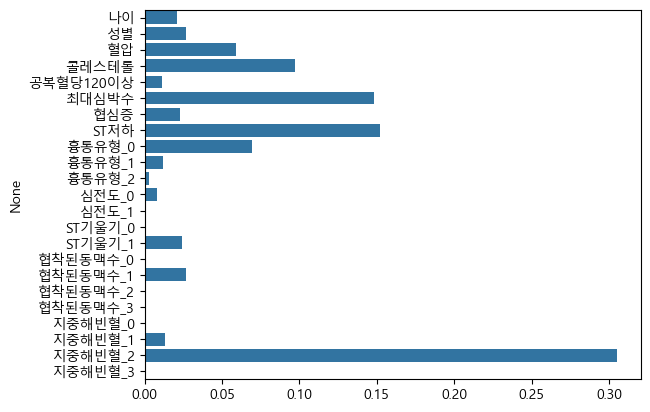

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'

sns.barplot(x=dtc.feature_importances_, y=feature.columns)
plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Classifier의 Decision Boundary를 시각화 하는 함수
def visualize_boundary(model, X, y):
    fig,ax = plt.subplots()
    
    # 학습 데이타 scatter plot으로 나타내기
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start , xlim_end = ax.get_xlim()
    ylim_start , ylim_end = ax.get_ylim()
    
    # 호출 파라미터로 들어온 training 데이타로 model 학습 . 
    model.fit(X.values, y)
    # meshgrid 형태인 모든 좌표값으로 예측 수행. 
    xx, yy = np.meshgrid(np.linspace(xlim_start,xlim_end, num=200),np.linspace(ylim_start,ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # contourf() 를 이용하여 class boundary 를 visualization 수행. 
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow',
                           zorder=1)

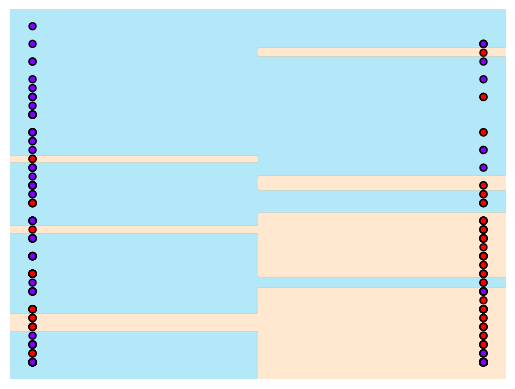

In [33]:
visualize_boundary(dtc, feature[["지중해빈혈_2", "ST저하"]], target)

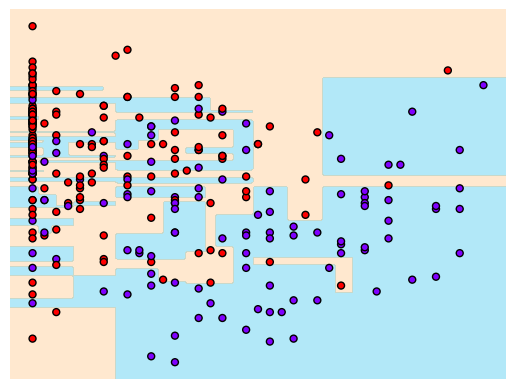

In [34]:
visualize_boundary(dtc, feature[["ST저하", "최대심박수"]], target)

### 과적합이 일어난걸 확인할수 있었다.

In [35]:
dtc.fit(X_train.values, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,124
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


### 오차행렬을 확인해본다

#### 정밀도 재현율 판단
> True Positive (TP): 모델이 심장병 환자를 환자로 판단 하였다.
> False Positive (FP): 모델이 심장병 환자를 정상이라고 판단 하였다. (오진)
> True Negative (TN): 모델이 정상 환자를 정상으로 판단 하였다.
> False Negative (FN): 모델이 심장병 환자를 정상으로 판단 하였다. (놓침)

- 정밀도 (Precision): 모델이 심장병으로 예측한 환자 중에서 실제 심장병 환자의 비율을 나타낸다. 즉, 양성으로 예측한 결과 중 얼마나 많은 것이 진짜 양성인지 측정한다.
- 재현율 (Recall): 실제 심장병 환자 중에서 모델이 심장병으로 정확하게 예측한 환자의 비율을 나타낸다. 즉, 모델이 얼마나 많은 환자를 "놓치지 않고" 감지했는지 측정한다.

- ※임계치를 낮추어서 재현율을 높여주는 것이 적합하다.

In [36]:
prediction = dtc.predict(X_test.values)

오차 행렬
[[17  9]
 [ 8 24]]
정확도: 0.7069, 정밀도: 0.7273, 재현율: 0.7500, F1:0.7385, AUC:0.7019
###########################################################################


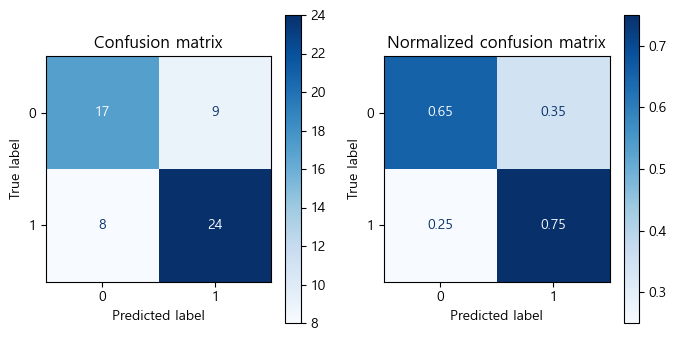

In [37]:
get_evaluation(y_test, prediction, classifier=dtc, X_test=X_test.values)

### 과적합 현상을 줄이기 위해 최적의 파라미터를 찾는 과정을 거치도록 한다.

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint

feature = heart_enc_df.iloc[:, :-1]
target = heart_enc_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(feature, 
                 target, 
                 test_size=0.2, 
                 stratify=target, 
                 random_state=124)

dtc = DecisionTreeClassifier()

parameters = {
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 20)
}

random_cv = RandomizedSearchCV(
    dtc,
    param_distributions=parameters,
    n_iter=4,
    cv=5,
    refit=True,
    return_train_score=True,
    random_state=124
)

random_cv.fit(X_train.values, y_train)

,estimator,DecisionTreeClassifier()
,param_distributions,"{'max_depth': <scipy.stats....00234DAA72C50>, 'min_samples_split': <scipy.stats....00234DAC9B4F0>}"
,n_iter,4
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,124
,error_score,nan


In [39]:
random_cv_scores = pd.DataFrame(random_cv.cv_results_)
random_cv_scores[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

,params,mean_test_score,rank_test_score
2,"{'max_depth': 3, 'min_samples_split': 2}",0.792507,1
0,"{'max_depth': 8, 'min_samples_split': 19}",0.783719,2
3,"{'max_depth': 6, 'min_samples_split': 16}",0.775023,3
1,"{'max_depth': 9, 'min_samples_split': 4}",0.749214,4


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from scipy.stats import randint

feature = heart_enc_df.iloc[:, :-1]
target = heart_enc_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(feature, 
                 target, 
                 test_size=0.2, 
                 stratify=target, 
                 random_state=124)

dtc = DecisionTreeClassifier(random_state = 124)

parameters = {
    'max_depth' : list(range(3, 10)),
    'min_samples_split': list(range(2, 20))
}

grid_cv = GridSearchCV(
    dtc,
    param_grid=parameters,
    cv=5,
    refit=True,
    return_train_score=True,
)

grid_cv.fit(X_train.values, y_train)

,estimator,DecisionTreeC...dom_state=124)
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [41]:
dtc = grid_cv.best_estimator_

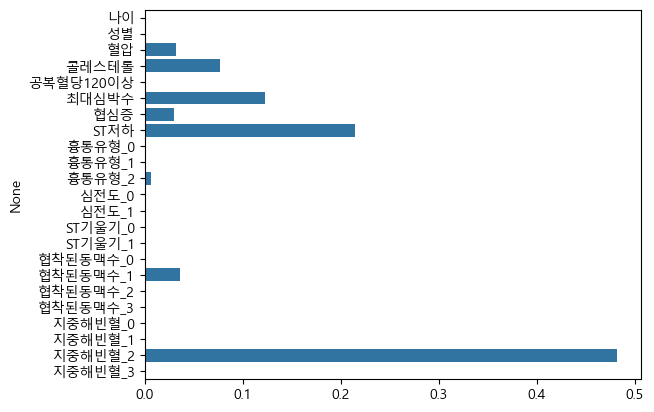

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=dtc.feature_importances_, y=feature.columns)
plt.show()

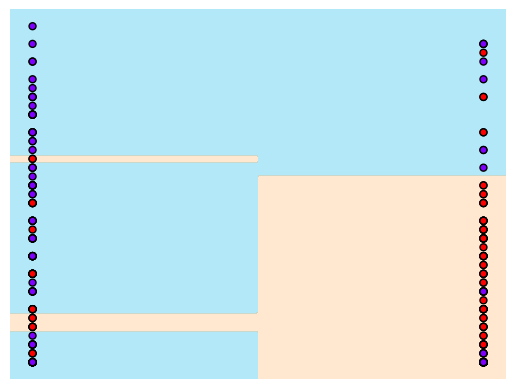

In [43]:
visualize_boundary(dtc, feature[["지중해빈혈_2", "ST저하"]], target)

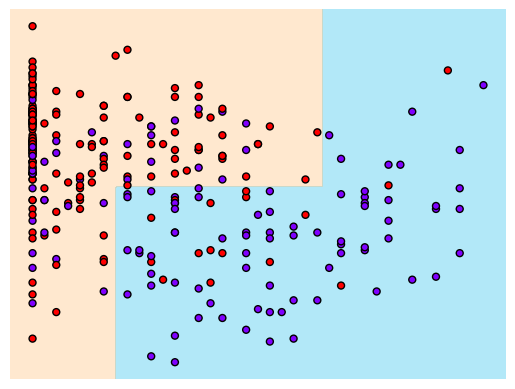

In [44]:
visualize_boundary(dtc, feature[["ST저하", "최대심박수"]], target)

In [45]:
grid_cv.fit(X_train.values, y_train)

,estimator,DecisionTreeC...dom_state=124)
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [46]:
dtc = grid_cv.best_estimator_
prediction = dtc.predict(X_test.values)

오차 행렬
[[16 10]
 [ 5 27]]
정확도: 0.7414, 정밀도: 0.7297, 재현율: 0.8438, F1:0.7826, AUC:0.7296
###########################################################################


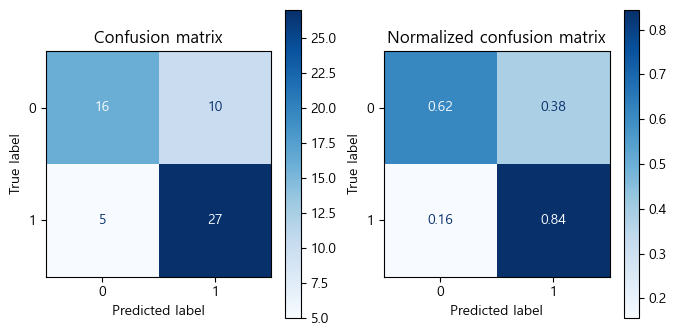

In [47]:
get_evaluation(y_test, prediction, classifier=dtc, X_test=X_test.values)

### 재현율이 상승한걸 확인할수 있었다.

##### 해당 파라미터로 나머지 작업을 진행하도록 한다.

In [48]:
### from sklearn.metrics import precision_recall_curve

prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, -1]

precisions, recalls, thresholds = \
precision_recall_curve(y_test, prediction_proba_class1)

print(thresholds)
print(precisions)
print(recalls)

[0.         0.01960784 0.14285714 0.18181818 0.33333333 0.4
 0.66666667 0.91578947 1.        ]
[0.55172414 0.54385965 0.63636364 0.66666667 0.675      0.69230769
 0.72972973 0.75757576 0.6        1.        ]
[1.      0.96875 0.875   0.875   0.84375 0.84375 0.84375 0.78125 0.09375
 0.     ]


In [49]:
dtc = grid_cv.best_estimator_

In [50]:
prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, -1]

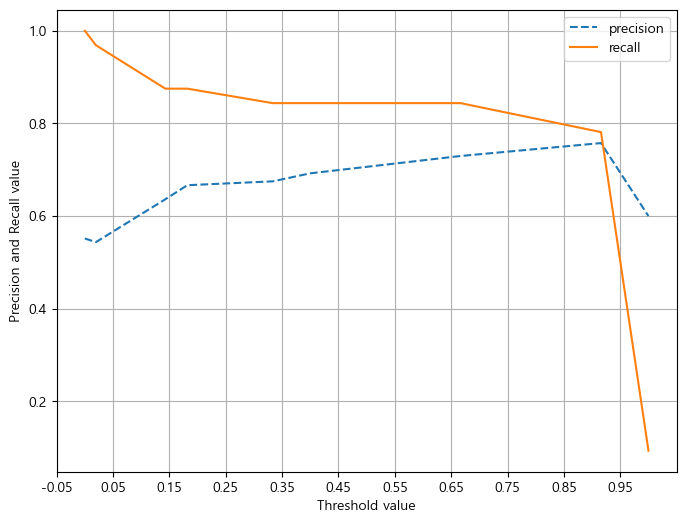

In [51]:
import matplotlib as mpl

plt.rcParams['font.family'] = 'Malgun Gothic'
mpl.rc('axes', unicode_minus=False)

precision_recall_curve_plot(y_test, prediction_proba_class1)

### 임계값을 낮추어 재현율을 더 높이는것도 좋지만, 이미 높은 재현율 이기에 비교적 낮은 정밀도를 위해 올려보았다.

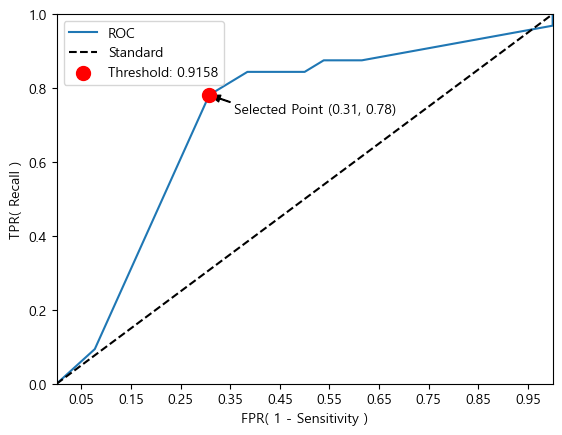

In [52]:
roc_curve_plot(y_test, prediction_proba_class1, 0.91578947)

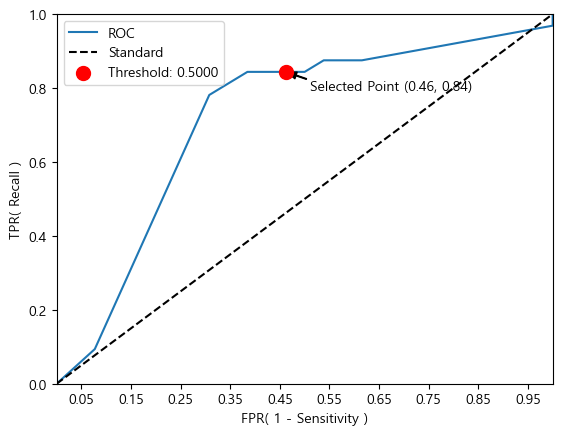

In [53]:
roc_curve_plot(y_test, prediction_proba_class1, 0.5)

In [54]:
from sklearn.metrics import precision_recall_curve

prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, -1]

precisions, recalls, thresholds = \
precision_recall_curve(y_test, prediction_proba_class1)

print(thresholds)
print(precisions)
print(recalls)

[0.         0.01960784 0.14285714 0.18181818 0.33333333 0.4
 0.66666667 0.91578947 1.        ]
[0.55172414 0.54385965 0.63636364 0.66666667 0.675      0.69230769
 0.72972973 0.75757576 0.6        1.        ]
[1.      0.96875 0.875   0.875   0.84375 0.84375 0.84375 0.78125 0.09375
 0.     ]


In [55]:
prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, 1]
binarizer = Binarizer(threshold=0.91578947)
prediction = binarizer.fit_transform(prediction_proba_class1.reshape(-1, 1))
auc_score = roc_auc_score(y_test, prediction)
print(f'ROC AUC 값: {auc_score}')

ROC AUC 값: 0.7367788461538461


오차 행렬
[[18  8]
 [ 7 25]]
정확도: 0.7414, 정밀도: 0.7576, 재현율: 0.7812, F1:0.7692, AUC:0.7368
###########################################################################


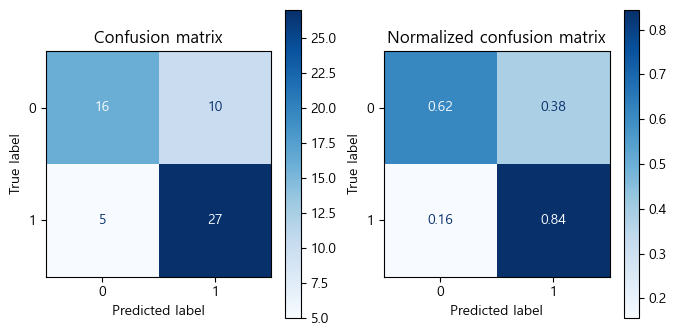

In [56]:
get_evaluation(y_test, prediction, classifier=dtc, X_test=X_test.values)

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 평가 지표 출력 및 오차행렬 시각화 함수
def get_evaluation(y_test, prediction):
    # 오차 행렬
    confusion = confusion_matrix(y_test, prediction)
    # 정확도
    accuracy = accuracy_score(y_test, prediction)
    # 정밀도
    precision = precision_score(y_test, prediction)
    # 재현율
    recall = recall_score(y_test, prediction)
    # F1 score
    f1 = f1_score(y_test, prediction)
    # ROC-AUC
    roc_auc = roc_auc_score(y_test, prediction)

    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))
    print("#" * 75)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    titles_options = [("Confusion matrix", None), ("Normalized confusion matrix", "true")]

    for (title, normalize), ax in zip(titles_options, axes.flatten()):
        disp = ConfusionMatrixDisplay.from_predictions(
            y_true=y_test, y_pred=prediction, ax=ax, cmap=plt.cm.Blues, normalize=normalize
        )
        disp.ax_.set_title(title)
    plt.show()


In [2]:
from sklearn.preprocessing import Binarizer

# 타겟 데이터와 예측 객체를 전달받는다.
def get_evaluation_by_thresholds(y_test, prediction_proba_class1, thresholds):
    for threshold in thresholds:
        binarizer = Binarizer(threshold=threshold).fit(prediction_proba_class1) 
        custom_prediction = binarizer.transform(prediction_proba_class1)
        print('임곗값:', threshold)
        get_evaluation(y_test, custom_prediction)

In [3]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def precision_recall_curve_plot(y_test, prediction_proba_class1):

    precisions, recalls, thresholds = precision_recall_curve(y_test, prediction_proba_class1)
    
    # X축: threshold
    # Y축: 정밀도, 재현율 
    # 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
    
    # X축(threshold)의 Scale을 0 ~ 1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()

In [4]:
from sklearn.metrics import roc_curve, roc_auc_score

def roc_curve_plot(y_test, prediction_proba_class1, custom_threshold=None):
#     임계값에 따른 FPR, TPR 값
    fprs, tprs, thresholds = roc_curve(y_test ,prediction_proba_class1)

#     ROC Curve를 plot 곡선으로 그림. 
    plt.plot(fprs , tprs, label='ROC')
#     가운데 대각선 직선을 그림. 
#     TPR과 FPR이 동일한 비율로 떨어진다는 것은 모델이 양성과 음성을 구별하지 못한다는 것을 의미한다.
#     다른 분류기를 판단하기 위한 기준선으로 사용되며, 
#     대각선에 가까울 수록 예측에 사용하기 힘든 모델이라는 뜻이다.
    plt.plot([0, 1], [0, 1], 'k--', label='Standard')

    # 설정한 임계값 지점 표시하기
    if custom_threshold is not None:
        # 설정한 임계값과 가장 가까운 지점 찾기
        idx = np.argmin(np.abs(thresholds - custom_threshold))
        plt.scatter(fprs[idx], tprs[idx], color='red', s=100, 
                    label=f'Threshold: {custom_threshold:.4f}', zorder=5)
        # 지점에 텍스트 추가
        plt.annotate(f'Selected Point ({fprs[idx]:.2f}, {tprs[idx]:.2f})', 
                     (fprs[idx], tprs[idx]), xytext=(fprs[idx]+0.05, tprs[idx]-0.05),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5, headlength=7))
    
    # X축(FPR)의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel('FPR( 1 - Sensitivity )'); plt.ylabel('TPR( Recall )')
    plt.legend()
    plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Classifier의 Decision Boundary를 시각화 하는 함수
def visualize_boundary(model, X, y):
    fig,ax = plt.subplots()
    
    # 학습 데이타 scatter plot으로 나타내기
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start , xlim_end = ax.get_xlim()
    ylim_start , ylim_end = ax.get_ylim()
    
    # 호출 파라미터로 들어온 training 데이타로 model 학습 . 
    model.fit(X.values, y)
    # meshgrid 형태인 모든 좌표값으로 예측 수행. 
    xx, yy = np.meshgrid(np.linspace(xlim_start,xlim_end, num=200),np.linspace(ylim_start,ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # contourf() 를 이용하여 class boundary 를 visualization 수행. 
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow',
                           zorder=1)